# 24 — Does lesion vimentin really differ between mild and severe chronic EAE?

Notebooks 11–18: astrocyte vimentin inside lesions (minus outside, within-image z) is higher in chronic MILD than
SEVERE animals. Notebooks 20 and 23 then showed two anatomy traps (distance to grey matter; mixing white and grey
matter). Here the mild–severe vimentin difference is re-tested under the same kind of controls, **animal by animal**,
and shown in the tissue.

Animals: MILD16 (3) and SEVERE16 (3) share the same run-5 images; MILD30 (5, run 1) vs SEVERE30 (2, run 5) are in
different runs. Measure (notebook 18): median astrocyte vimentin (cell mean, robust z within image; 18S-segmented
cells) inside lesion regions minus astrocytes > 60 µm outside. Checks:
1. white matter and grey matter separately;
2. matched for region **and depth from the cord surface** (subpial astrocytes of the glia limitans are naturally
   vimentin-rich, and lesions are often subpial): inside − outside within each region × depth band (0–50, 50–150,
   > 150 µm from the tissue edge), averaged over bands;
3. deep cells only (> 150 µm from the surface); reactive astrocytes only;
4. the channel calibrator: vascular smooth muscle cells (VSMC) in the same αSMA/vimentin channel.

Then many images: every animal's lesion white matter next to its own healthy white matter at the same depth, with
identical display scaling (within-image z), and mild vs severe animals from the *same image* side by side.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, spearmanr
from skimage.segmentation import find_boundaries

from beyondboundaries import data, plotting
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/24_vimentin_mild_vs_severe.ipynb"
OUT = ROOT / "results" / "24_vimentin_mild_vs_severe"
OUT.mkdir(parents=True, exist_ok=True)
STAGES = ["MILD16", "SEVERE16", "MILD30", "SEVERE30"]
GCOL = {"MILD": "#2e86c1", "SEVERE": "#c0392b"}
GM = ["GM", "DorsalHorn", "VentralHorn"]
WM = ["WM", "WM_Meningeal"]

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "run_id", "Anno_L1_curated", "Anno_L2",
             "Global_anatomical_region", "x_centroid", "y_centroid", "cell_id"]].copy()
a.file.close()
for c in ["sample_name", "meta_sample_id", "sample_id", "stage", "run_id", "Anno_L1_curated", "Anno_L2",
          "Global_anatomical_region", "cell_id"]:
    obs[c] = obs[c].astype(str)
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet")[["lesion_state"]])
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion16" / "regions.parquet"))
fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet",
                     columns=["section_id", "segmentation_method", "smavim_cell_mean", "edge_um"])
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"]
med = fa.smavim_cell_mean.groupby(fa.section_id).transform("median")
mad = (fa.smavim_cell_mean - med).abs().groupby(fa.section_id).transform("median") * 1.4826
fa["vim_z"] = (fa.smavim_cell_mean - med) / mad
SEC_SCALE = pd.DataFrame({"med": fa.groupby("section_id").smavim_cell_mean.median(),
                          "mad": (fa.smavim_cell_mean - med).abs().groupby(fa.section_id).median() * 1.4826})
obs = obs.join(fa[["vim_z", "edge_um"]])
# cells < 20 µm from another tissue piece excluded (pieces touch in runs 1-3), as in notebook 18
other = pd.Series(np.inf, index=obs.index)
for _, g in obs.groupby("sample_id"):
    xy, pc = g[["x_centroid", "y_centroid"]].to_numpy(), g.meta_sample_id.to_numpy()
    for p in np.unique(pc):
        m = pc == p
        if not m.all():
            other[g.index[m]] = cKDTree(xy[~m]).query(xy[m])[0]
obs.loc[other < 20, "vim_z"] = np.nan
obs["rclass"] = np.select([obs.Global_anatomical_region.isin(WM), obs.Global_anatomical_region.isin(GM)], ["WM", "GM"],
                          "other")
sub = obs[obs.stage.isin(STAGES)].copy()
sub["group"] = sub.stage.str.replace(r"\d+", "", regex=True)
ast = sub[(sub.Anno_L1_curated == "Astrocyte") & sub.vim_z.notna()].copy()
ast["inside"] = ast.reg_dist > 0
ast["outside"] = ast.reg_dist < -60
ast["depth"] = pd.cut(ast.edge_um, [-1, 50, 150, 1e6], labels=["0–50 µm", "50–150 µm", "> 150 µm"])
print(ast.groupby("stage").sample_name.nunique().to_dict(), f"{len(ast):,} astrocytes")

{'MILD16': 3, 'MILD30': 5, 'SEVERE16': 3, 'SEVERE30': 2} 24,033 astrocytes


In [3]:
def contrast(s, min_n=15):
    i, o = s[s.inside], s[s.outside]
    if len(i) < min_n or len(o) < min_n:
        return np.nan
    return i.vim_z.median() - o.vim_z.median()


def stratified(s, keys, min_n=10):
    vals = []
    for _, g in s.groupby(keys, observed=True):
        i, o = g[g.inside], g[g.outside]
        if len(i) >= min_n and len(o) >= min_n:
            vals.append(i.vim_z.median() - o.vim_z.median())
    return np.mean(vals) if vals else np.nan


CHECKS = {
    "original (notebook 18)": lambda s: contrast(s),
    "white matter only": lambda s: contrast(s[s.rclass == "WM"]),
    "grey matter only": lambda s: contrast(s[s.rclass == "GM"]),
    "matched region × depth from surface": lambda s: stratified(s, ["rclass", "depth"]),
    "deep only (> 150 µm from surface)": lambda s: contrast(s[s.edge_um > 150]),
    "reactive astrocytes only": lambda s: contrast(s[s.Anno_L2.str.contains("Reactive", case=False)]),
}
rows = {}
for an, s in ast.groupby("sample_name"):
    i, o = s[s.inside], s[s.outside]
    rows[an] = dict(stage=s.stage.iloc[0], group=s.group.iloc[0], run=s.run_id.iloc[0], astro_inside=len(i),
                    **{k: f(s) for k, f in CHECKS.items()},
                    inside_WM_share=(i.rclass == "WM").mean(), inside_depth_um=i.edge_um.median(),
                    outside_depth_um=o.edge_um.median())
A = pd.DataFrame(rows).T
for c in A.columns[3:]:
    A[c] = A[c].astype(float)
vsmc = sub[sub.Anno_L1_curated == "VSMC"].groupby("sample_name").vim_z.median()
A["VSMC vimentin (calibrator)"] = vsmc
A = A.sort_values(["stage", "original (notebook 18)"])
A.round(2).to_csv(OUT / "per_animal.csv")
A.round(2)

,stage,group,run,astro_inside,original (notebook 18),white matter only,grey matter only,matched region × depth from surface,deep only (> 150 µm from surface),reactive astrocytes only,inside_WM_share,inside_depth_um,outside_depth_um,VSMC vimentin (calibrator)
C_M16_1,MILD16,MILD,run5,232.0,0.93,0.91,0.10,0.53,0.18,0.88,0.81,97.40,396.29,0.80
C_M16_2,MILD16,MILD,run5,764.0,2.27,3.56,-0.01,1.49,0.71,1.98,0.72,173.14,396.13,1.90
C_M16_3,MILD16,MILD,run5,180.0,6.01,5.62,NaN,3.21,2.24,3.18,0.92,82.78,382.76,3.18
C_L_3,MILD30,MILD,run1,705.0,2.46,3.64,0.48,3.05,1.82,1.27,0.79,154.70,361.42,1.93
C_L_2,MILD30,MILD,run1,541.0,2.49,2.71,0.18,0.54,1.33,1.51,0.90,104.59,380.36,1.38
C_L_1,MILD30,MILD,run1,435.0,3.30,2.94,NaN,1.58,1.99,0.61,0.97,113.02,437.17,0.68
C_L_5,MILD30,MILD,run1,463.0,6.99,8.90,0.11,3.19,2.25,2.98,0.83,103.24,378.67,2.68
C_L_4,MILD30,MILD,run1,441.0,8.17,7.80,-0.05,3.67,9.20,4.18,0.89,146.76,344.40,1.01
C_S16_1,SEVERE16,SEVERE,run5,775.0,0.12,0.51,0.02,0.55,0.07,-1.73,0.65,221.66,272.43,0.62
C_S16_2,SEVERE16,SEVERE,run5,1227.0,1.01,1.53,0.17,0.86,0.40,0.22,0.71,122.13,113.02,0.74


In [4]:
rows = []
for lab, d in [("MILD16 vs SEVERE16 (same images)", A[A.stage.isin(["MILD16", "SEVERE16"])]),
               ("MILD30 vs SEVERE30 (different runs)", A[A.stage.isin(["MILD30", "SEVERE30"])]),
               ("all mild vs all severe", A)]:
    for c in list(CHECKS) + ["VSMC vimentin (calibrator)"]:
        m, s_ = d[d.group == "MILD"][c].dropna(), d[d.group == "SEVERE"][c].dropna()
        if len(m) and len(s_):
            rows.append(dict(comparison=lab, check=c, mild_median=m.median(), severe_median=s_.median(),
                             n_mild=len(m), n_severe=len(s_), every_mild_above_every_severe=bool(m.min() > s_.max()),
                             p_one_sided=mannwhitneyu(m, s_, alternative="greater").pvalue))
T = pd.DataFrame(rows)
T.round(3).to_csv(OUT / "mild_vs_severe_tests.csv", index=False)
T.round(3)

,comparison,check,mild_median,severe_median,n_mild,n_severe,every_mild_above_every_severe,p_one_sided
0,MILD16 vs SEVERE16 (same images),original (notebook 18),2.267,1.013,3,3,False,0.200
1,MILD16 vs SEVERE16 (same images),white matter only,3.561,1.269,3,3,False,0.200
2,MILD16 vs SEVERE16 (same images),grey matter only,0.041,0.053,2,3,False,0.800
3,MILD16 vs SEVERE16 (same images),matched region × depth from surface,1.485,0.774,3,3,False,0.350
4,MILD16 vs SEVERE16 (same images),deep only (> 150 µm from surface),0.713,0.404,3,3,False,0.200
5,MILD16 vs SEVERE16 (same images),reactive astrocytes only,1.980,0.220,3,3,True,0.050
6,MILD16 vs SEVERE16 (same images),VSMC vimentin (calibrator),1.903,0.744,3,3,False,0.100
7,MILD30 vs SEVERE30 (different runs),original (notebook 18),3.300,2.065,5,2,True,0.048
8,MILD30 vs SEVERE30 (different runs),white matter only,3.645,2.168,5,2,True,0.048
9,MILD30 vs SEVERE30 (different runs),grey matter only,0.141,0.162,4,2,False,0.600


**Every animal, every check.** One dot per animal (blue mild, red severe; circles = the 16 cohort sharing images,
squares = the 30 cohort). The y-axis is the inside − outside lesion astrocyte vimentin (within-image z units).

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/24_vimentin_mild_vs_severe/per_animal_checks.png')

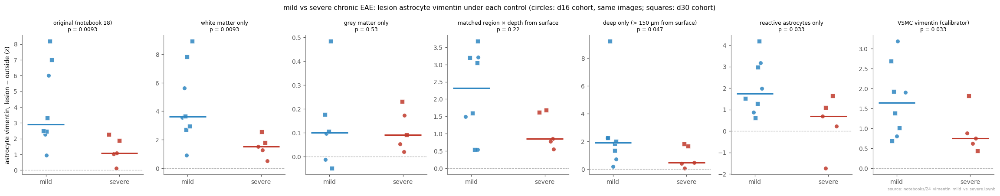

In [5]:
cks = list(CHECKS) + ["VSMC vimentin (calibrator)"]
fig, axs = plt.subplots(1, len(cks), figsize=(3.0 * len(cks), 4), sharey=False)
rng = np.random.default_rng(0)
for ax, c in zip(axs, cks):
    for k, grp in enumerate(["MILD", "SEVERE"]):
        d = A[A.group == grp]
        for coh, mk in [("16", "o"), ("30", "s")]:
            dd = d[d.stage.str.endswith(coh)]
            ax.scatter(k + rng.normal(0, 0.06, len(dd)), dd[c], color=GCOL[grp], marker=mk, s=40, alpha=0.85,
                       edgecolor="white", lw=0.5)
        ax.hlines(d[c].median(), k - 0.25, k + 0.25, color=GCOL[grp], lw=2)
    ax.axhline(0, color="0.7", lw=0.8, ls="--")
    ax.set_xticks([0, 1], ["mild", "severe"])
    t = T[(T.comparison == "all mild vs all severe") & (T.check == c)]
    ax.set_title(f"{c}\np = {t.p_one_sided.iloc[0]:.2g}" if len(t) else c, fontsize=8)
axs[0].set_ylabel("astrocyte vimentin, lesion − outside (z)")
fig.suptitle("mild vs severe chronic EAE: lesion astrocyte vimentin under each control (circles: d16 cohort, "
             "same images; squares: d30 cohort)", fontsize=10)
fig.tight_layout()
plotting.save_fig(fig, "per_animal_checks", OUT, SRC)

**Why depth matters.** Astrocyte vimentin against depth from the cord surface, outside lesions (healthy reference)
and inside, per group: if vimentin is high near the pia anyway, a lesion that sits near the pia looks
"vimentin-rich" against a deeper reference.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/24_vimentin_mild_vs_severe/vimentin_vs_depth.png')

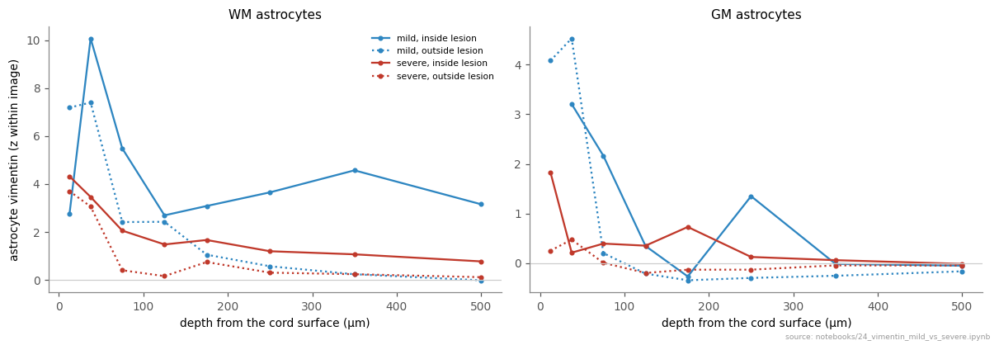

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
bins = [0, 25, 50, 100, 150, 200, 300, 400, 600]
for ax, rc in zip(axs, ["WM", "GM"]):
    for grp in ["MILD", "SEVERE"]:
        for where, ls in [("inside", "-"), ("outside", ":")]:
            d = ast[(ast.group == grp) & ast[where] & (ast.rclass == rc)]
            m = d.groupby(pd.cut(d.edge_um, bins), observed=True).vim_z.median()
            ax.plot([b.mid for b in m.index], m.values, ls=ls, marker="o", ms=3, color=GCOL[grp],
                    label=f"{grp.lower()}, {where} lesion")
    ax.set_xlabel("depth from the cord surface (µm)")
    ax.set_title(f"{rc} astrocytes")
    ax.axhline(0, color="0.8", lw=0.8)
axs[0].set_ylabel("astrocyte vimentin (z within image)")
axs[0].legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "vimentin_vs_depth", OUT, SRC)

## Images
Display: the αSMA/vimentin channel alone, scaled per image from its own raw pixels (1st to 99.5th percentile of
tissue pixels on a downsampled copy of the whole image), so the scale is identical for every animal on the same
image and comparable in rank terms between images. Cell outlines thin grey; **astrocytes outlined in cyan**.
Crops 80 µm, centred on a random astrocyte (seed 0; not chosen for the effect).

In [7]:
bundles = find_bundles(data.load_config())
_B, _L = {}, {}


def cell_labels(sid):
    if sid not in _L:
        c = pd.read_parquet(bundles[sid] / "cells.parquet", columns=["cell_id"]).cell_id
        _L[sid] = pd.Series(np.arange(1, len(c) + 1), index=c.to_numpy())
    return _L[sid]


_R = {}


def display_range(sid, level=3):
    """1st and 99.5th percentile of tissue pixels of the αSMA/vimentin channel (2**level downsampled whole image)."""
    if sid not in _R:
        if sid not in _B:
            _B[sid] = XeniumBundle(bundles[sid])
        im = _B[sid].read_level("smavim", level).astype(np.float32)
        v = im[im > 0]
        _R[sid] = (np.percentile(v, 1), np.percentile(v, 99.5))
    return _R[sid]


def crop(ax, r, w_um=80, title=""):
    sid = r.sample_id
    if sid not in _B:
        _B[sid] = XeniumBundle(bundles[sid])
    b = _B[sid]
    px = b.pixel_size
    x0, y0 = r.x_centroid - w_um / 2, r.y_centroid - w_um / 2
    img, lab, _ = b.read_window(int(y0 / px), int(x0 / px), int(w_um / px), int(w_um / px))
    lo, hi = display_range(sid)
    ax.imshow(np.clip((img[3] - lo) / (hi - lo), 0, 1), cmap="inferno", extent=(0, w_um, w_um, 0))
    near = sub[(sub.sample_id == sid) & sub.x_centroid.between(x0, x0 + w_um) & sub.y_centroid.between(y0, y0 + w_um)]
    astro_lab = cell_labels(sid).reindex(near[near.Anno_L1_curated == "Astrocyte"].cell_id).dropna().astype(int)
    ov = np.zeros((*lab.shape, 4))
    e = find_boundaries(lab, mode="inner")
    ov[e] = (0.6, 0.6, 0.6, 0.35)
    ov[e & np.isin(lab, astro_lab.to_numpy())] = (0.2, 0.9, 1, 1)
    ax.imshow(ov, extent=(0, w_um, w_um, 0))
    ax.set_title(title, fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])


def pick(s, n, rng):
    return s.iloc[rng.choice(len(s), size=min(n, len(s)), replace=False)] if len(s) else s

### Every animal: lesion white matter vs its own healthy white matter at the same depth
One row per animal (grouped mild → severe, d16 then d30). Left four: random white-matter astrocytes **inside**
lesion regions; right two: random white-matter astrocytes **outside** (> 60 µm), matched to the depth from the
surface of the first two lesion crops (± 30 µm). Number in each title = that astrocyte's vimentin z.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/24_vimentin_mild_vs_severe/gallery_every_animal.png')

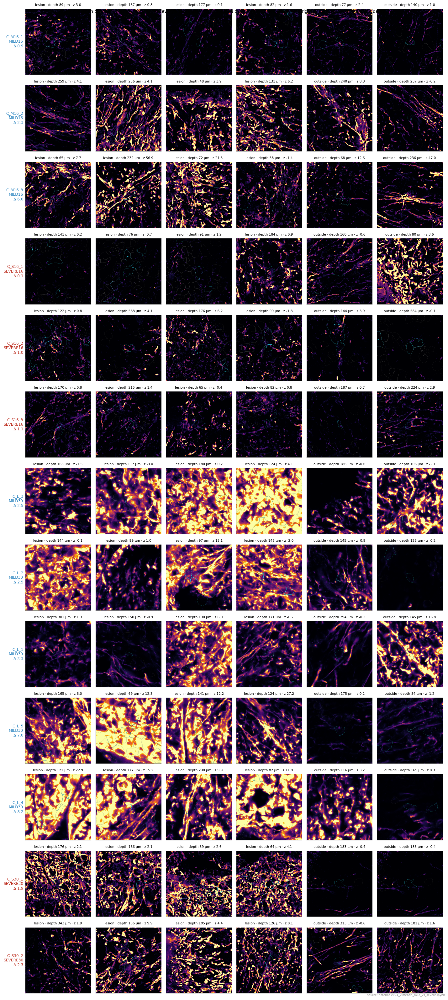

In [8]:
order = [an for st in ["MILD16", "SEVERE16", "MILD30", "SEVERE30"] for an in A[A.stage == st].index]
rng = np.random.default_rng(0)
fig, axs = plt.subplots(len(order), 6, figsize=(13, 2.25 * len(order)))
for i, an in enumerate(order):
    s = ast[(ast.sample_name == an) & (ast.rclass == "WM")]
    ins = pick(s[s.reg_dist > 30], 4, rng)
    for j, (_, r) in enumerate(ins.iterrows()):
        crop(axs[i, j], r, title=f"lesion · depth {r.edge_um:.0f} µm · z {r.vim_z:.1f}")
    out = s[s.outside]
    for j in range(2):
        if j < len(ins):
            d0 = ins.iloc[j].edge_um
            cand = out[(out.edge_um - d0).abs() <= 30]
            if len(cand):
                r = cand.iloc[rng.integers(len(cand))]
                crop(axs[i, 4 + j], r, title=f"outside · depth {r.edge_um:.0f} µm · z {r.vim_z:.1f}")
                continue
        axs[i, 4 + j].axis("off")
        axs[i, 4 + j].set_title("no depth-matched outside astrocyte", fontsize=7)
    st = A.loc[an]
    axs[i, 0].set_ylabel(f"{an}\n{st.stage}\nΔ {st['original (notebook 18)']:.1f}", fontsize=8,
                         color=GCOL[st.group], rotation=0, ha="right", va="center")
fig.suptitle("αSMA/vimentin channel (inferno, same z scale everywhere); astrocytes outlined cyan. Left 4: inside "
             "lesion WM; right 2: outside WM at the same depth", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "gallery_every_animal", OUT, SRC)

### Same image, mild next to severe
MILD16 and SEVERE16 animals sit on the same slides (run 5), so imaging and staining are shared. For each image that
holds both, four random lesion white-matter astrocyte crops from a mild and a severe animal, deep cells only
(> 150 µm from the surface) so the glia-limitans effect is excluded.

images with both MILD16 and SEVERE16 animals: ['run5_C2_G1_Bot_0088858', 'run5_C2_G2_Mid_0088858', 'run5_C2_G2_Top_0088858', 'run5_C2_G3_Mid_0088870']


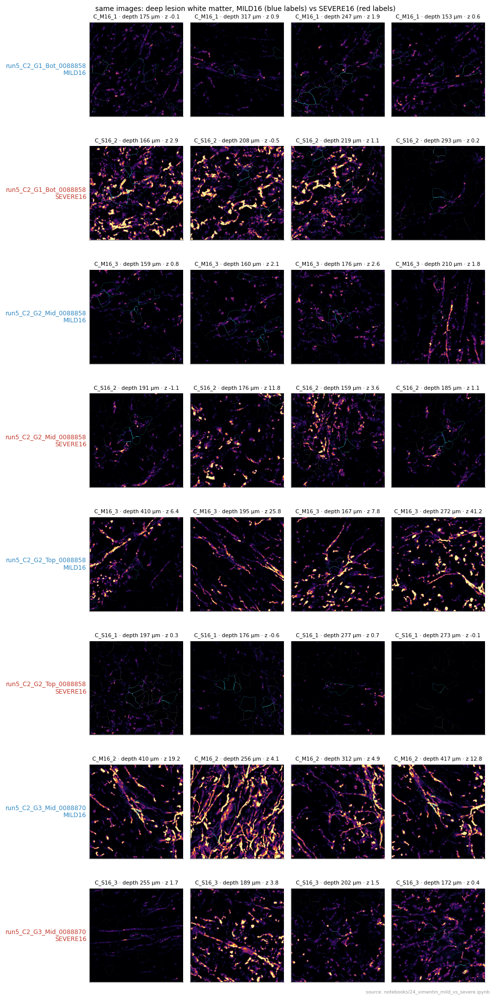

In [9]:
both = sub[sub.stage.isin(["MILD16", "SEVERE16"])].groupby("sample_id").stage.agg(lambda x: set(x))
shared = [sid for sid, st in both.items() if {"MILD16", "SEVERE16"} <= st]
print("images with both MILD16 and SEVERE16 animals:", shared)
rng = np.random.default_rng(1)
rows_ = []
for sid in shared:
    for st in ["MILD16", "SEVERE16"]:
        s = ast[(ast.sample_id == sid) & (ast.stage == st) & (ast.rclass == "WM") & (ast.reg_dist > 30) & (ast.edge_um > 150)]
        rows_.append((sid, st, pick(s, 4, rng)))
rows_ = [r for r in rows_ if len(r[2])]
if rows_:
    fig, axs = plt.subplots(len(rows_), 4, figsize=(9, 2.3 * len(rows_)), squeeze=False)
    for i, (sid, st, s) in enumerate(rows_):
        for j in range(4):
            if j < len(s):
                r = s.iloc[j]
                crop(axs[i, j], r, title=f"{r.sample_name} · depth {r.edge_um:.0f} µm · z {r.vim_z:.1f}")
            else:
                axs[i, j].axis("off")
        axs[i, 0].set_ylabel(f"{sid}\n{st}", fontsize=8, color=GCOL[st[:-2]], rotation=0, ha="right", va="center")
    fig.suptitle("same images: deep lesion white matter, MILD16 (blue labels) vs SEVERE16 (red labels)", fontsize=9)
    fig.tight_layout()
    plotting.save_fig(fig, "gallery_same_image_deep", OUT, SRC)

### Near the surface vs deep, inside lesions
The same animals, lesion white-matter astrocytes near the surface (< 50 µm) vs deep (> 150 µm): is the vimentin
seen in lesions mostly the glia limitans? Three random crops each, every animal with enough cells.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/24_vimentin_mild_vs_severe/gallery_surface_vs_deep.png')

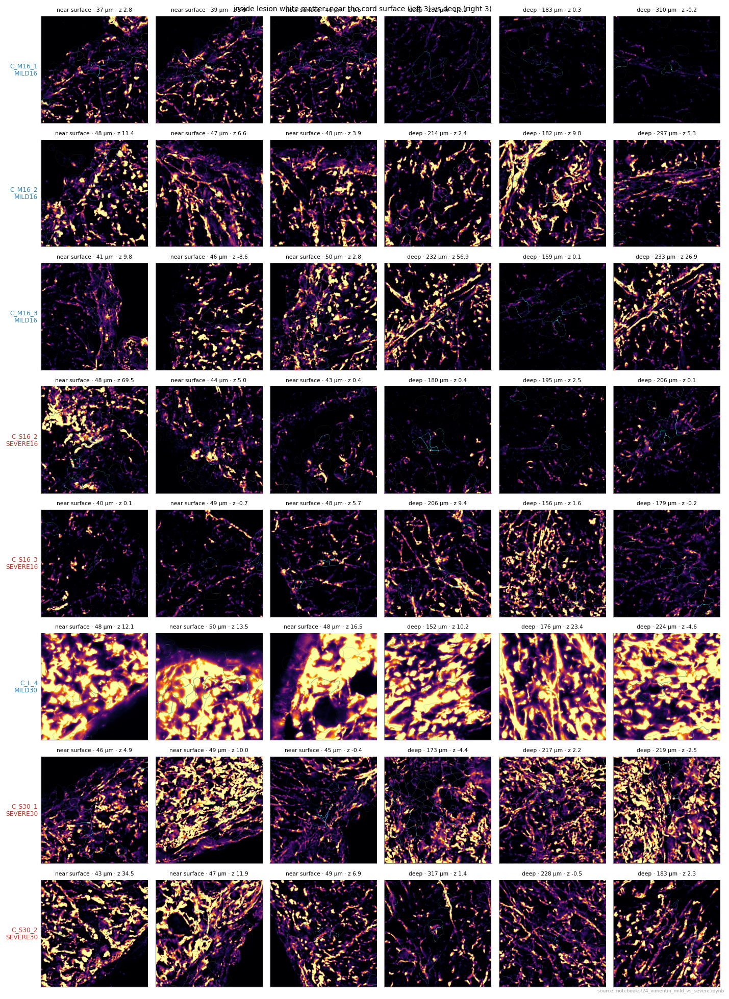

In [10]:
rng = np.random.default_rng(2)
ok = [an for an in order if ((ast.sample_name == an) & (ast.rclass == "WM") & (ast.reg_dist > 30) & (ast.edge_um < 50)).sum() >= 3
      and ((ast.sample_name == an) & (ast.rclass == "WM") & (ast.reg_dist > 30) & (ast.edge_um > 150)).sum() >= 3]
fig, axs = plt.subplots(len(ok), 6, figsize=(13, 2.25 * len(ok)), squeeze=False)
for i, an in enumerate(ok):
    s = ast[(ast.sample_name == an) & (ast.rclass == "WM") & (ast.reg_dist > 30)]
    for j, (_, r) in enumerate(pick(s[s.edge_um < 50], 3, rng).iterrows()):
        crop(axs[i, j], r, title=f"near surface · {r.edge_um:.0f} µm · z {r.vim_z:.1f}")
    for j, (_, r) in enumerate(pick(s[s.edge_um > 150], 3, rng).iterrows()):
        crop(axs[i, 3 + j], r, title=f"deep · {r.edge_um:.0f} µm · z {r.vim_z:.1f}")
    st = A.loc[an]
    axs[i, 0].set_ylabel(f"{an}\n{st.stage}", fontsize=8, color=GCOL[st.group], rotation=0, ha="right", va="center")
fig.suptitle("inside lesion white matter: near the cord surface (left 3) vs deep (right 3)", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "gallery_surface_vs_deep", OUT, SRC)

## Findings

> **Mild > severe holds in direction, but it is weak and not established (exploratory).**
> - **Only in white matter.** In grey matter mild and severe are identical (lesion − outside ≈ 0.1 in both).
> - **Depth from the cord surface is a confound.** Lesion astrocytes sit ~100–200 µm from the surface, their healthy
>   reference ~350–400 µm, and astrocyte vimentin is highest near the pia (glia limitans). Matching region and depth
>   roughly halves the difference (all mild vs severe 2.32 vs 0.86, p = 0.22, 8 vs 5 animals); deep cells only
>   (> 150 µm): 1.91 vs 0.45, p = 0.047. In the depth profile, deep lesion white matter is z ≈ 3–4.5 in mild vs
>   ≈ 1–1.5 in severe while healthy white matter at the same depth is ≈ 0–1 in both: the best support for a real
>   difference.
> - **The channel calibrator moves too.** VSMC vimentin, in the same αSMA/vimentin channel, is also higher in mild
>   animals (1.64 vs 0.74, p = 0.03), as is the healthy glia limitans near the surface, so part of the difference is
>   likely piece-level channel brightness, not astrocyte biology.
> - **Small groups.** MILD16 vs SEVERE16 (same images, 3 vs 3): no check separates them completely except reactive
>   astrocytes only (p = 0.05). MILD30 vs SEVERE30 compares run 1 with run 5, and the run-1 images look different
>   (softer focus, different dynamic range), so that contrast is not a fair visual or quantitative comparison.
> - **By eye (same-image gallery, deep lesion white matter).** In two of the four shared images the mild animal's
>   lesion is clearly brighter (G2_Top: C_M16_3 vs C_S16_1; G3_Mid: C_M16_2 vs C_S16_3); in one the severe animal's
>   is brighter (G1_Bot: C_S16_2 vs C_M16_1); one is similar. In the every-animal gallery, lesions are brighter than
>   the animal's own healthy white matter at the same depth in most animals of both groups.
>
> **Status:** lesions are vimentin-richer than surrounding white matter in both mild and severe animals; that mild
> lesions are *more* vimentin-rich is a consistent direction that weakens under depth matching and is partly shared
> by the channel calibrator. Keep as exploratory; settling it needs a separate vimentin antibody (not pooled with
> αSMA) on the MILD16/SEVERE16 slides, or more animals per group.